## Import Libraries

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Load Titanic dataset from Kaggle

In [22]:
df = pd.read_csv("Titanic-Dataset.csv")
print("First 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows:
   PassengerId  Survived  Pclass                                               Name     Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked
0            1         0       3                            Braund, Mr. Owen Harris    male  22.0      1      0         A/5 21171   7.2500   NaN        S
1            2         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1      0          PC 17599  71.2833   C85        C
2            3         1       3                             Heikkinen, Miss. Laina  female  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S
3            4         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0            113803  53.1000  C123        S
4            5         0       3                           Allen, Mr. William Henry    male  35.0      0      0            373450   8.0500   NaN        S

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entr

## 2. Clean data (handle missing values like Age).

In [26]:
# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill Embarked with most common value
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column (too many missing)
if 'Cabin' in df.columns:
    df = df.drop('Cabin', axis=1)
    
# Remove duplicates
df.drop_duplicates(inplace=True)
print("\nAfter Cleaning Missing Values:")
print(df.isnull().sum())


After Cleaning Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## 3. Answer questions such as:

#### (A) Who survived more: males or females?


In [33]:
gender_survival = df.groupby("Sex")["Survived"].mean()
print("Survival Rate by Gender:")
print(gender_survival)
if gender_survival['female'] > gender_survival['male']:
    print("\nAnswer: Females survived more than males.")
else:
    print("\nAnswer: Males survived more than females.")

Survival Rate by Gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Answer: Females survived more than males.


#### (B) Did passenger class affect survival chances?

In [31]:
class_survival = df.groupby("Pclass")["Survived"].mean()
print("\nSurvival Rate by Passenger Class:")
print(class_survival)
print("\nAnswer: Yes, passenger class affected survival chances.")
print("Higher class passengers had better survival rate.")


Survival Rate by Passenger Class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Answer: Yes, passenger class affected survival chances.
Higher class passengers had better survival rate.


#### (C) What was the survival rate by age group?

In [34]:
df['AgeGroup'] = pd.cut(df['Age'],
                        bins=[0, 18, 60, 100],
                        labels=['Children', 'Adults', 'Seniors'])

age_survival = df.groupby("AgeGroup")["Survived"].mean()

print("\nSurvival Rate by Age Group:")
print(age_survival)
print("\nAnswer: Children had highest survival rate, seniors lowest.")


Survival Rate by Age Group:
AgeGroup
Children    0.503597
Adults      0.365753
Seniors     0.227273
Name: Survived, dtype: float64

Answer: Children had highest survival rate, seniors lowest.


## 4. Visualize using Seaborn / Matplotlib:

#### Bar chart of survival by gender.

Text(0.5, 1.0, 'Survival Rate by Gender')

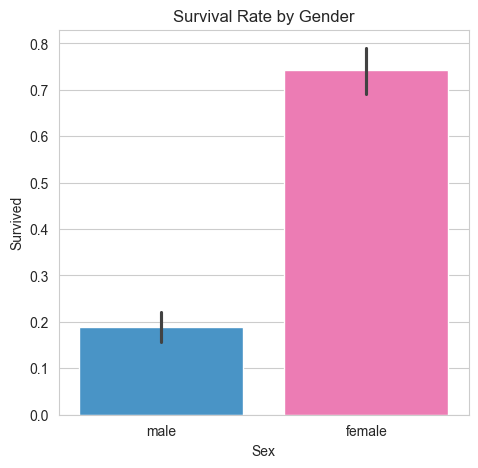

In [37]:
sns.set_style("whitegrid")
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.barplot(x="Sex", y="Survived", hue="Sex", data=df,
            palette=["#3498db", "#ff69b4"], legend=False)
plt.title("Survival Rate by Gender")

#### Bar chart of survival by class.

Text(0.5, 1.0, 'Survival Rate by Passenger Class')

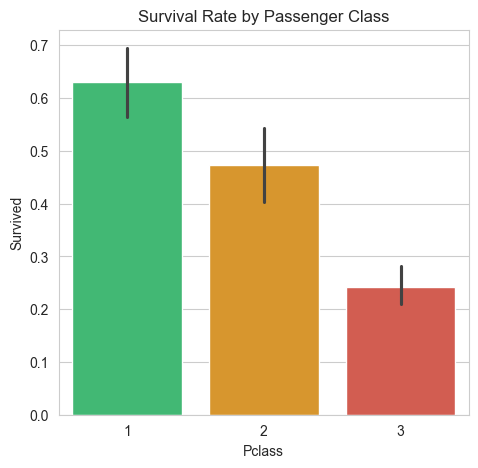

In [40]:
sns.set_style("whitegrid")
plt.figure(figsize=(18,5))

plt.subplot(1,3,2)
sns.barplot(x="Pclass", y="Survived", hue="Pclass", data=df,
            palette=["#2ecc71", "#f39c12", "#e74c3c"], legend=False)
plt.title("Survival Rate by Passenger Class")

#### Histogram of passenger ages.

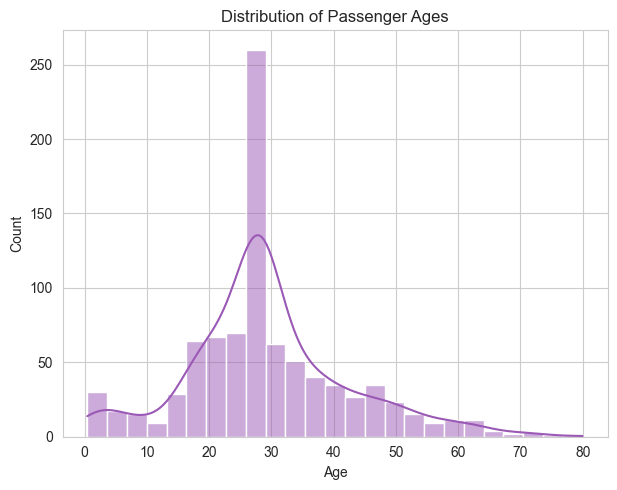

In [43]:
sns.set_style("whitegrid")
plt.figure(figsize=(18,5))

plt.subplot(1,3,3)
sns.histplot(df["Age"], bins=25, color="#9b59b6", kde=True)
plt.title("Distribution of Passenger Ages")

plt.tight_layout()
plt.show()